# Appendix A — Tables A1, A2, A3 (v2)

Clean replication of the three calibration tables from Romagnoli & Sartini (2025), Appendix A.1.

This notebook delegates all computation to `solarrpy.calibration.calibrate_all_windows` — the
same pipeline that backs every downstream notebook (Phases 3–5).  No calibration logic is
re-implemented here; we only format and display.

**Training windows**: 2005–2013 through 2005–2022 (ten windows total).

### Table A1 — Clear-sky & transform parameters
| Column | Meaning |
|---|---|
| α, β | Gumbel-transform lower/upper bounds |
| δ₀, δ₁, δ₂, δ₃ | Clear-sky model coefficients |
| a₀, a₁, a₂ | Seasonal mean Y coefficients |

### Table A2 — Variance & mean-reversion parameters
| Column | Meaning |
|---|---|
| θ | OU mean-reversion speed (martingale estimator) |
| b₀, b₁, b₂ | Discrete-time variance OLS (residual ε²) |
| γ₀, γ₁, γ₂ | Long-run volatility (continuous-time, Proposition A.2) |
| c₀, c₁, c₂ | Short-run volatility (continuous-time, Proposition A.2) |

### Table A3 — Per-month Gaussian mixture (training window 2005–2013)
Two-component EM fitted to standardised residuals ε̃_t per calendar month.
State 1 = cloudy (lower mean), State 0 = sunny (higher mean).
Means are corrected by √(I/J) to account for discrete→continuous-time discrepancy.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from IPython.display import display, HTML

from solarrpy.calibration import calibrate_all_windows

## 0. Load data and run all calibration windows

In [2]:
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
print(f'Dataset: {len(df)} rows, {df["Year"].min()}–{df["Year"].max()}')

df = df.drop(columns=['H0']).copy()  # H0 is computed internally, and the provided values are not trustworthy

# Bologna Coordinates used in the paper
LATITUDE = 44.4949
LONGITUDE = 11.3426
ALTITUDE = 71

result = calibrate_all_windows(
    df,
    coords={'lat': LATITUDE},
    target_col='GHI',
    clearsky_col='clearsky',
    date_col='date',
    optimiser='delta_optimiser',
    progress=True,
)

print(f'\nDone. {len(result.windows)} windows calibrated.')

Dataset: 7465 rows, 2005–2025
[calibrate_all_windows] training period 2005-2013 ...
[calibrate_all_windows] training period 2005-2014 ...
[calibrate_all_windows] training period 2005-2015 ...
[calibrate_all_windows] training period 2005-2016 ...
[calibrate_all_windows] training period 2005-2017 ...
[calibrate_all_windows] training period 2005-2018 ...
[calibrate_all_windows] training period 2005-2019 ...
[calibrate_all_windows] training period 2005-2020 ...
[calibrate_all_windows] training period 2005-2021 ...
[calibrate_all_windows] training period 2005-2022 ...

Done. 10 windows calibrated.


## 1. Table A1 — Clear-sky & transform parameters

Columns: training window, N obs, α, β, δ₀–δ₃ (± SE), a₀–a₂ (± SE).

In [3]:
a1 = result.table_a1.copy()

def fmt_se(val, se, digits_val=4, digits_se=4):
    return f"{val:.{digits_val}f}<br><span style='font-size:0.85em;color:#555'>({se:.{digits_se}f})</span>"

display_a1 = pd.DataFrame({
    'Train years': a1['train_years'],
    'N':           a1['n_obs'].astype(int),
    'α':           a1['alpha'].map('{:.6f}'.format),
    'β':           a1['beta'].map('{:.4f}'.format),
    'δ₀':          a1.apply(lambda r: fmt_se(r['delta0'], r['delta0_err']), axis=1),
    'δ₁':          a1.apply(lambda r: fmt_se(r['delta1'], r['delta1_err']), axis=1),
    'δ₂':          a1.apply(lambda r: fmt_se(r['delta2'], r['delta2_err']), axis=1),
    'δ₃':          a1.apply(lambda r: fmt_se(r['delta3'], r['delta3_err']), axis=1),
    'a₀':          a1.apply(lambda r: fmt_se(r['a0'], r['a0_err']), axis=1),
    'a₁':          a1.apply(lambda r: fmt_se(r['a1'], r['a1_err']), axis=1),
    'a₂':          a1.apply(lambda r: fmt_se(r['a2'], r['a2_err']), axis=1),
})

TABLE_CSS = [
    {'selector': 'thead th',
     'props': 'border-bottom:1px solid black; border-top:2px solid black; '
              'text-align:center; padding:6px 10px; background:#fafafa;'},
    {'selector': 'tbody tr:last-child td',
     'props': 'border-bottom:2px solid black;'},
    {'selector': 'tbody td',
     'props': 'text-align:center; vertical-align:middle; padding:5px 10px;'},
    {'selector': 'tbody td:nth-child(1)',
     'props': 'text-align:left; font-weight:500;'},
    # Section dividers
    {'selector': 'th:nth-child(3), td:nth-child(3)',
     'props': 'border-left:1px solid #bbb;'},
    {'selector': 'th:nth-child(5), td:nth-child(5)',
     'props': 'border-left:1px solid #bbb;'},
    {'selector': 'th:nth-child(9), td:nth-child(9)',
     'props': 'border-left:1px solid #bbb;'},
]

print('Table A1 — Clear-sky & transform parameters (SE in parentheses)')
display(
    display_a1.style
               .set_table_styles(TABLE_CSS)
               .hide(axis='index')
               .set_caption('Table A1: Constrained OLS clear-sky + Gumbel transform + seasonal mean Y')
)

Table A1 — Clear-sky & transform parameters (SE in parentheses)


Train years,N,α,β,δ₀,δ₁,δ₂,δ₃,a₀,a₁,a₂
2005-2013,3287,0.000606,0.9230,-1.1721(0.3598),0.9460(0.0483),0.0111(0.0358),0.5094(0.2058),-0.0721(0.0163),-0.0731(0.0231),-0.3886(0.0231)
2005-2014,3652,0.000159,0.9236,-1.0821(0.3409),0.9360(0.0457),0.0250(0.0339),0.4507(0.1950),-0.0879(0.0154),-0.0675(0.0218),-0.3838(0.0218)
2005-2015,4017,0.000958,0.9229,-1.3128(0.3224),0.9673(0.0432),0.0004(0.0321),0.5857(0.1844),-0.0782(0.0146),-0.0606(0.0207),-0.3724(0.0207)
2005-2016,4383,0.000375,0.9234,-1.2383(0.3104),0.9568(0.0416),0.0061(0.0309),0.5414(0.1776),-0.0797(0.0141),-0.0661(0.0199),-0.3707(0.0199)
2005-2017,4748,0.000250,0.9236,-1.1569(0.2972),0.9457(0.0399),0.0190(0.0296),0.4965(0.1700),-0.0627(0.0134),-0.0637(0.0190),-0.3667(0.0190)
2005-2018,5113,0.000363,0.9234,-1.1278(0.2873),0.9407(0.0385),0.0223(0.0286),0.4839(0.1643),-0.0627(0.0130),-0.0764(0.0184),-0.3738(0.0183)
2005-2019,5478,0.000168,0.9238,-1.2987(0.2776),0.9634(0.0372),0.0125(0.0276),0.5881(0.1588),-0.0546(0.0125),-0.0729(0.0177),-0.3595(0.0177)
2005-2020,5844,0.001180,0.9229,-1.3221(0.2679),0.9675(0.0359),0.0115(0.0267),0.6016(0.1533),-0.0434(0.0121),-0.0642(0.0171),-0.3522(0.0171)
2005-2021,6209,0.000910,0.9233,-1.4952(0.2610),0.9917(0.0350),-0.0009(0.0260),0.7008(0.1493),-0.0444(0.0116),-0.0594(0.0165),-0.3499(0.0165)
2005-2022,6574,0.000090,0.9242,-1.6634(0.2548),1.0147(0.0342),-0.0169(0.0253),0.7963(0.1457),-0.0390(0.0113),-0.0537(0.0159),-0.3472(0.0159)


In [4]:
# Raw numeric Table A1 for inspection / export
print(a1[['train_years','n_obs','alpha','beta',
           'delta0','delta1','delta2','delta3',
           'a0','a1','a2']].to_string(index=False, float_format='{:.6f}'.format))

train_years  n_obs    alpha     beta    delta0   delta1    delta2   delta3        a0        a1        a2
  2005-2013   3287 0.000606 0.923012 -1.172075 0.945978  0.011062 0.509449 -0.072126 -0.073140 -0.388598
  2005-2014   3652 0.000159 0.923649 -1.082100 0.935959  0.024977 0.450707 -0.087928 -0.067534 -0.383760
  2005-2015   4017 0.000958 0.922926 -1.312827 0.967297  0.000410 0.585669 -0.078221 -0.060571 -0.372384
  2005-2016   4383 0.000375 0.923413 -1.238346 0.956823  0.006092 0.541418 -0.079663 -0.066075 -0.370692
  2005-2017   4748 0.000250 0.923589 -1.156905 0.945706  0.018967 0.496496 -0.062718 -0.063678 -0.366727
  2005-2018   5113 0.000363 0.923407 -1.127849 0.940712  0.022252 0.483927 -0.062661 -0.076359 -0.373761
  2005-2019   5478 0.000168 0.923758 -1.298724 0.963351  0.012468 0.588097 -0.054633 -0.072862 -0.359550
  2005-2020   5844 0.001180 0.922864 -1.322064 0.967464  0.011523 0.601551 -0.043360 -0.064232 -0.352217
  2005-2021   6209 0.000910 0.923330 -1.495200 0.991748

## 2. Table A2 — Variance & mean-reversion parameters

Columns: training window, θ, b₀–b₂ (± SE), γ₀–γ₂, c₀–c₂.

In [5]:
a2 = result.table_a2.copy()
a2['train_years'] = '2005-' + a2['train_end_year'].astype(str)

display_a2 = pd.DataFrame({
    'Train years': a2['train_years'],
    'θ':           a2['theta'].map('{:.4f}'.format),
    'b₀':          a2.apply(lambda r: fmt_se(r['b0'], r['b0_err']), axis=1),
    'b₁':          a2.apply(lambda r: fmt_se(r['b1'], r['b1_err']), axis=1),
    'b₂':          a2.apply(lambda r: fmt_se(r['b2'], r['b2_err']), axis=1),
    'γ₀':          a2['gamma0'].map('{:.6f}'.format),
    'γ₁':          a2['gamma1'].map('{:.6f}'.format),
    'γ₂':          a2['gamma2'].map('{:.6f}'.format),
    'c₀':          a2['c0'].map('{:.6f}'.format),
    'c₁':          a2['c1'].map('{:.6f}'.format),
    'c₂':          a2['c2'].map('{:.6f}'.format),
})

TABLE_CSS_A2 = TABLE_CSS + [
    {'selector': 'th:nth-child(3), td:nth-child(3)',
     'props': 'border-left:1px solid #bbb;'},
    {'selector': 'th:nth-child(6), td:nth-child(6)',
     'props': 'border-left:1px solid #bbb;'},
    {'selector': 'th:nth-child(9), td:nth-child(9)',
     'props': 'border-left:1px solid #bbb;'},
]

print('Table A2 — Variance & mean-reversion parameters (SE in parentheses for b)')
display(
    display_a2.style
               .set_table_styles(TABLE_CSS_A2)
               .hide(axis='index')
               .set_caption('Table A2: OU θ + discrete b + continuous-time γ, c (Proposition A.2)')
)

Table A2 — Variance & mean-reversion parameters (SE in parentheses for b)


Train years,θ,b₀,b₁,b₂,γ₀,γ₁,γ₂,c₀,c₁,c₂
2005-2013,0.9240,0.7359(0.0266),0.1292(0.0376),0.4278(0.0376),0.873562,0.155028,0.507297,1.614325,0.277756,0.940143
2005-2014,0.9397,0.7295(0.0244),0.1205(0.0345),0.4148(0.0345),0.860986,0.143769,0.489108,1.618108,0.261776,0.921688
2005-2015,0.9369,0.7264(0.0232),0.1138(0.0328),0.4069(0.0328),0.858134,0.135887,0.480236,1.607948,0.246355,0.902193
2005-2016,0.9524,0.7345(0.0220),0.1145(0.0311),0.4192(0.0311),0.863003,0.135981,0.492087,1.643803,0.250538,0.939641
2005-2017,0.9599,0.7292(0.0212),0.1180(0.0299),0.4275(0.0299),0.854497,0.139780,0.500549,1.640490,0.259738,0.963377
2005-2018,0.9760,0.7347(0.0210),0.1254(0.0296),0.4396(0.0296),0.856231,0.147628,0.511925,1.671333,0.279353,1.001801
2005-2019,0.9700,0.7308(0.0201),0.1209(0.0284),0.4152(0.0284),0.853479,0.142586,0.484499,1.655831,0.268291,0.942428
2005-2020,0.9696,0.7250(0.0193),0.1106(0.0273),0.4053(0.0273),0.846797,0.130595,0.472980,1.642155,0.245115,0.919477
2005-2021,0.9792,0.7175(0.0184),0.1012(0.0261),0.4005(0.0261),0.835370,0.119124,0.465958,1.635916,0.225261,0.914542
2005-2022,0.9669,0.7078(0.0177),0.0979(0.0251),0.3885(0.0251),0.827496,0.115799,0.453862,1.600224,0.216122,0.879680


In [6]:
# Raw numeric Table A2
print(a2[['train_years','theta','b0','b1','b2','gamma0','gamma1','gamma2','c0','c1','c2']]
        .to_string(index=False, float_format='{:.6f}'.format))

train_years    theta       b0       b1       b2   gamma0   gamma1   gamma2       c0       c1       c2
  2005-2013 0.923990 0.735928 0.129230 0.427802 0.873562 0.155028 0.507297 1.614325 0.277756 0.940143
  2005-2014 0.939683 0.729525 0.120535 0.414817 0.860986 0.143769 0.489108 1.618108 0.261776 0.921688
  2005-2015 0.936886 0.726373 0.113757 0.406869 0.858134 0.135887 0.480236 1.607948 0.246355 0.902193
  2005-2016 0.952374 0.734537 0.114481 0.419194 0.863003 0.135981 0.492087 1.643803 0.250538 0.939641
  2005-2017 0.959916 0.729200 0.118024 0.427517 0.854497 0.139780 0.500549 1.640490 0.259738 0.963377
  2005-2018 0.975982 0.734651 0.125418 0.439606 0.856231 0.147628 0.511925 1.671333 0.279353 1.001801
  2005-2019 0.970048 0.730842 0.120903 0.415244 0.853479 0.142586 0.484499 1.655831 0.268291 0.942428
  2005-2020 0.969627 0.725018 0.110646 0.405294 0.846797 0.130595 0.472980 1.642155 0.245115 0.919477
  2005-2021 0.979156 0.717503 0.101187 0.400512 0.835370 0.119124 0.465958 1.63591

## 3. Table A3 — Monthly Gaussian mixture

Two-component EM fitted to standardised OU residuals ε̃_t, per calendar month.

- **State 1 (Cloudy, B_t=1)**: component with lower mean μ₁
- **State 0 (Sunny, B_t=0)**: component with higher mean μ₀
- Means corrected by √(I/J) (continuous→discrete discrepancy)
- Mixture moments (mean, variance, skewness, kurtosis) computed analytically from corrected parameters

Display one window at a time; use the selector cell below to choose which training year to show.

In [7]:
# ── Selector: change SHOW_YEAR to display a different training window ──
SHOW_YEAR = 2022   # options: 2013..2022

a3 = result.table_a3[SHOW_YEAR].copy()

display_a3 = pd.DataFrame({
    'Month':   a3['Month_abbr'],
    'N':       a3['n_obs'].astype(int),
    'P(B=1)':  a3['p'].map('{:.2f}'.format),
    'μ₁':      a3['mu1'].map('{:.2f}'.format),
    'σ₁':      a3['sd1'].map('{:.2f}'.format),
    'N₁':      a3['N1'].astype(int),
    'μ₀':      a3['mu0'].map('{:.2f}'.format),
    'σ₀':      a3['sd0'].map('{:.2f}'.format),
    'N₀':      a3['N0'].astype(int),
    'Mean':    a3['mean'].map('{:.3f}'.format),
    'Var':     a3['variance'].map('{:.2f}'.format),
    'Skew':    a3['skewness'].map('{:.2f}'.format),
    'Kurt':    a3['kurtosis'].map('{:.3f}'.format),
})

TABLE_CSS_A3 = [
    {'selector': 'thead th',
     'props': 'border-bottom:1px solid black; border-top:2px solid black; '
              'text-align:center; padding:5px 8px; background:#fafafa;'},
    {'selector': 'tbody tr:last-child td',
     'props': 'border-bottom:2px solid black;'},
    {'selector': 'tbody td',
     'props': 'text-align:center; vertical-align:middle; padding:4px 8px;'},
    {'selector': 'tbody td:nth-child(1)',
     'props': 'text-align:left; font-weight:500;'},
    # Section dividers: Cloudy | Sunny | Moments
    {'selector': 'th:nth-child(3), td:nth-child(3)',
     'props': 'border-left:1px solid #bbb;'},
    {'selector': 'th:nth-child(7), td:nth-child(7)',
     'props': 'border-left:1px solid #bbb;'},
    {'selector': 'th:nth-child(10), td:nth-child(10)',
     'props': 'border-left:1px solid #bbb;'},
]

print(f'Table A3 — Monthly Gaussian mixture (training window 2005–{SHOW_YEAR})')
display(
    display_a3.style
               .set_table_styles(TABLE_CSS_A3)
               .hide(axis='index')
               .set_caption(
                   f'Table A3 (2005–{SHOW_YEAR}): '
                   'Two-component EM per calendar month — standardised OU residuals ε̃_t'
               )
)

Table A3 — Monthly Gaussian mixture (training window 2005–2022)


Month,N,P(B=1),μ₁,σ₁,N₁,μ₀,σ₀,N₀,Mean,Var,Skew,Kurt
Jan,557,0.40,-0.87,0.75,209,0.62,0.51,348,0.020,0.92,-0.55,-0.307
Feb,508,0.49,-0.63,1.23,209,0.64,0.39,299,0.025,1.22,-0.98,0.803
Mar,558,0.27,-1.17,0.96,127,0.51,0.51,431,0.062,0.98,-1.11,1.059
Apr,540,0.40,-0.83,1.04,185,0.53,0.41,355,-0.019,0.98,-1.05,0.749
May,558,0.28,-1.36,1.19,129,0.34,0.57,429,-0.132,1.20,-1.17,1.437
Jun,540,0.21,-1.44,1.16,89,0.30,0.57,451,-0.057,1.03,-1.30,2.140
Jul,558,0.30,-0.73,1.19,129,0.43,0.40,429,0.083,0.82,-1.40,2.557
Aug,558,0.21,-1.13,1.21,93,0.45,0.46,465,0.121,0.89,-1.61,3.225
Sep,540,0.27,-1.15,0.99,128,0.51,0.49,412,0.063,0.97,-1.18,1.231
Oct,558,0.26,-1.45,0.98,133,0.46,0.56,425,-0.047,1.19,-1.04,0.784


## 4. All ten Table A3 windows — summary statistics

In [8]:
# Print terminal-return-style summary: avg p, avg |μ₁|, avg μ₀ per training year
summary_rows = []
for year, a3_df in sorted(result.table_a3.items()):
    summary_rows.append({
        'Train years': f'2005-{year}',
        'avg P(B=1)':  a3_df['p'].mean(),
        'avg μ₁':      a3_df['mu1'].mean(),
        'avg μ₀':      a3_df['mu0'].mean(),
        'avg σ₁':      a3_df['sd1'].mean(),
        'avg σ₀':      a3_df['sd0'].mean(),
        'avg mean':    a3_df['mean'].mean(),
        'avg var':     a3_df['variance'].mean(),
    })

df_summary = pd.DataFrame(summary_rows)
print('Cross-window summary of Table A3 monthly GMM parameters:')
print(df_summary.to_string(index=False, float_format='{:.4f}'.format))

Cross-window summary of Table A3 monthly GMM parameters:
Train years  avg P(B=1)  avg μ₁  avg μ₀  avg σ₁  avg σ₀  avg mean  avg var
  2005-2013      0.3347 -1.0759  0.5016  0.9984  0.5028    0.0026   1.0185
  2005-2014      0.3519 -0.9763  0.5155  1.0221  0.4909    0.0013   1.0231
  2005-2015      0.3376 -1.0169  0.5016  1.0241  0.5009    0.0017   1.0210
  2005-2016      0.3265 -1.0621  0.5023  0.9955  0.5095    0.0019   1.0228
  2005-2017      0.3377 -1.0255  0.5048  0.9963  0.4997    0.0016   1.0234
  2005-2018      0.3398 -1.0382  0.5175  0.9901  0.5001    0.0017   1.0274
  2005-2019      0.3407 -1.0155  0.5131  1.0055  0.4973    0.0020   1.0237
  2005-2020      0.3343 -1.0322  0.5061  1.0059  0.5013    0.0020   1.0231
  2005-2021      0.3371 -1.0308  0.5101  1.0075  0.4988    0.0017   1.0245
  2005-2022      0.3277 -1.0563  0.5017  1.0106  0.5049    0.0017   1.0240


## 5. Export CSVs

In [9]:
import os
out_dir = '../results/appendixA'
os.makedirs(out_dir, exist_ok=True)

# Table A1
result.table_a1.to_csv(f'{out_dir}/TableA1.csv', index=False)
print(f'Saved {out_dir}/TableA1.csv  ({len(result.table_a1)} rows)')

# Table A2
result.table_a2.to_csv(f'{out_dir}/TableA2.csv', index=False)
print(f'Saved {out_dir}/TableA2.csv  ({len(result.table_a2)} rows)')

# Table A3 — one CSV per training window
for year, a3_df in sorted(result.table_a3.items()):
    path = f'{out_dir}/TableA3_{year}.csv'
    a3_df.to_csv(path, index=False)
print(f'Saved {len(result.table_a3)} TableA3_<year>.csv files to {out_dir}/')

print('\nAll done.')

Saved ../results/appendixA/TableA1.csv  (10 rows)
Saved ../results/appendixA/TableA2.csv  (10 rows)
Saved 10 TableA3_<year>.csv files to ../results/appendixA/

All done.


## 6. Gate checks

In [10]:
a1 = result.table_a1
a2 = result.table_a2

# Gate 1: 10 windows produced
assert len(result.windows) == 10, f'Expected 10 windows, got {len(result.windows)}'
print('GATE PASS: 10 calibration windows produced')

# Gate 2: α in (0,1), β in (0,1)
assert (a1['alpha'] > 0).all() and (a1['alpha'] < 1).all()
assert (a1['beta'] > 0).all() and (a1['beta'] < 1).all()
print('GATE PASS: α, β ∈ (0,1) for all windows')

# Gate 3: θ > 0 (mean-reverting)
assert (a2['theta'] > 0).all()
print(f'GATE PASS: θ > 0 for all windows  (range: {a2["theta"].min():.4f}–{a2["theta"].max():.4f})')

# Gate 4: b₀ (intercept of variance) > 0
assert (a2['b0'] > 0).all()
print('GATE PASS: b₀ > 0 (positive variance intercept)')

# Gate 5: each Table A3 has 12 months
for year, a3_df in result.table_a3.items():
    assert len(a3_df) == 12, f'Table A3 for {year} has {len(a3_df)} rows (expected 12)'
print('GATE PASS: All Table A3 windows have 12 months')

# Gate 6: mixture probabilities in (0,1)
for year, a3_df in result.table_a3.items():
    assert (a3_df['p'] > 0).all() and (a3_df['p'] < 1).all(), f'Invalid p in {year}'
print('GATE PASS: All mixture probabilities p ∈ (0,1)')

# Gate 7: μ₁ < μ₀ (cloudy state has lower mean)
for year, a3_df in result.table_a3.items():
    assert (a3_df['mu1'] < a3_df['mu0']).all(), f'μ₁ ≮ μ₀ in {year}'
print('GATE PASS: μ₁ < μ₀ (cloudy < sunny) for all months and windows')

print('\nAppendix A (v2) complete.')

GATE PASS: 10 calibration windows produced
GATE PASS: α, β ∈ (0,1) for all windows
GATE PASS: θ > 0 for all windows  (range: 0.9240–0.9792)
GATE PASS: b₀ > 0 (positive variance intercept)
GATE PASS: All Table A3 windows have 12 months
GATE PASS: All mixture probabilities p ∈ (0,1)
GATE PASS: μ₁ < μ₀ (cloudy < sunny) for all months and windows

Appendix A (v2) complete.


In [11]:
import pandas as pd
df = pd.read_csv('../results/appendixA/em_experiments/Final/kmeans_init_TableA3_2022.csv')
np.sqrt(df['J_avg'])/df['I_avg']

0     1.037648
1     1.037625
2     1.037856
3     1.038207
4     1.038629
5     1.038158
6     1.037680
7     1.038964
8     1.039409
9     1.038971
10    1.038298
11    1.037873
dtype: float64

In [12]:
b0_paper = [0.728, 0.723, 0.72, 0.73, 0.725, 0.732, 0.729, 0.723, 0.716, 0.707]
c0_paper = [1.58 , 1.59 , 1.58, 1.62, 1.62 , 1.66 , 1.64 , 1.63 , 1.63 , 1.59 ]
theta_paper = [0.67, 0.674, 0.673, 0.678, 0.68, 0.685, 0.683, 0.683, 0.685, 0.682]

## 7. Per-month standardised-residual histograms with EM mixture overlay

Histogram of ε̃_t = ε_t / √J(t-1,t,t) per calendar month, with the fitted two-component Gaussian mixture overlaid (cloudy = lower mean, sunny = higher mean, mixture = weighted sum).

Note: `monthly_mixture['mu1','mu0']` are stored post-correction (μ_B = μ_raw·√J/I). The EM was fit on ε̃ directly, so we undo the correction (divide by `mean_corr`) to plot the densities on the same axis as the histogram.

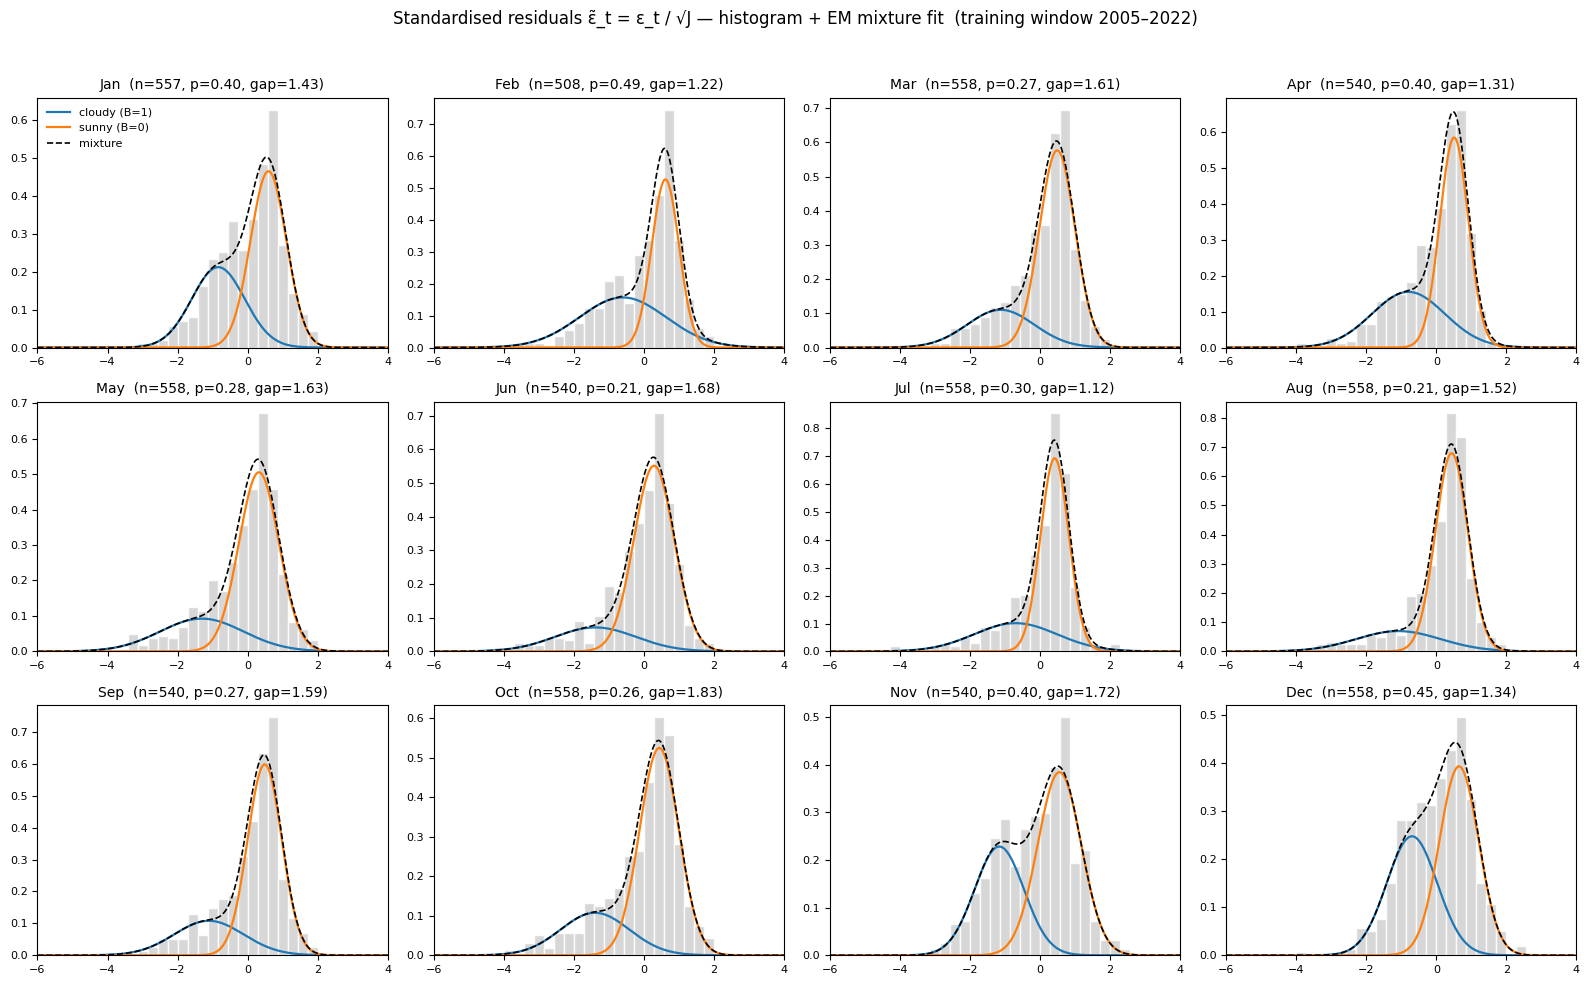

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Reuse the same selector as the Table A3 cell above
HIST_YEAR = SHOW_YEAR  # change to 2013..2022 to inspect a different window

win = next(w for w in result.windows if w.train_end_year == HIST_YEAR)
mix = win.monthly_mixture.set_index('Month')

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.ravel()
x_grid = np.linspace(-6, 4, 600)

for m in range(1, 13):
    ax = axes[m - 1]
    sub = win.df_train.loc[
        (win.df_train['Month'] == m) & win.df_train['eps_tilde'].notna(),
        'eps_tilde',
    ].values
    ax.hist(sub, bins=35, range=(-6, 4), density=True,
            color='lightgrey', edgecolor='white', alpha=0.9)

    if m in mix.index:
        row = mix.loc[m]
        # mu1/mu0 in monthly_mixture are post-correction (μ_B = μ_raw·√J/I).
        # Undo it so the EM density sits on the ε̃ histogram axis.
        corr = float(row['mean_corr'])
        mu1, mu0 = float(row['mu1']) / corr, float(row['mu0']) / corr
        sd1, sd0 = float(row['sd1']), float(row['sd0'])
        p1 = float(row['p'])
        d1 = p1 * norm.pdf(x_grid, mu1, sd1)
        d0 = (1 - p1) * norm.pdf(x_grid, mu0, sd0)
        ax.plot(x_grid, d1, color='#1f77b4', lw=1.6, label='cloudy (B=1)')
        ax.plot(x_grid, d0, color='#ff7f0e', lw=1.6, label='sunny (B=0)')
        ax.plot(x_grid, d1 + d0, color='black', lw=1.2, ls='--', label='mixture')
        ax.set_title(
            f"{row['Month_abbr']}  (n={int(row['n_obs'])}, "
            f"p={p1:.2f}, gap={mu0 - mu1:.2f})",
            fontsize=10,
        )
    else:
        ax.set_title(f'Month {m}', fontsize=10)

    ax.set_xlim(-6, 4)
    ax.tick_params(axis='both', labelsize=8)

axes[0].legend(loc='upper left', fontsize=8, frameon=False)
fig.suptitle(
    f'Standardised residuals ε̃_t = ε_t / √J — histogram + EM mixture fit  '
    f'(training window 2005–{HIST_YEAR})',
    fontsize=12,
)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
